# Decoding Probe — sprite world

A frozen-encoder probe decoder $d_\xi : z_t \to \hat{o}_t$ trained per control
setting (see `train_decoder.py`). Reconstructs held-out eval observations to show
what visual structure the latent retains.

In [21]:
import sys
from pathlib import Path

CWD = Path(".").resolve()
EXPERIMENT_DIR = CWD if (CWD / "config_xyt.yaml").exists() \
                 else CWD / "experiments" / "sprite_decoder"
REPO_ROOT = EXPERIMENT_DIR.parent.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from misc.plot_style import FULL_WIDTH, HALF_WIDTH, palette, apply_matplotlib_style, figure_size
apply_matplotlib_style()

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml

from train import build_world, materialize
from models import CNNEncoder, CNNDecoder

RUNS = ["none", "x", "xy", "xyt"]
RESULTS_DIR = EXPERIMENT_DIR / "results"
DOF_NAMES  = ["x", "y", "θ"]
CONTROLLED = {"none": set(), "x": {"x"}, "xy": {"x", "y"}, "xyt": {"x", "y", "θ"}}
RUN_COLOR = {
    "none": palette["Dark Grey"],
    "x":    palette["Dark Blue"],
    "xy":   palette["Med Purple"],
    "xyt":  palette["Dark Red"],
}
device = torch.device("cpu")

# Eval observations are identical across runs (the control mask does not affect
# rendering and the eval split shares its seed), so render them once from a
# reference config, then decode with each run's frozen encoder + probe decoder.
ref = next((r for r in RUNS if (RESULTS_DIR / r / "config.yaml").exists()), None)
obs_eval = states_eval = obs_np = None
recon = {}
if ref is not None:
    enc_cfg = yaml.safe_load((RESULTS_DIR / ref / "config.yaml").read_text())
    ds_cfg, m_cfg, t_cfg = enc_cfg["dataset"], enc_cfg["model"], enc_cfg["training"]
    world_cfg, DatasetClass, _ = build_world(ds_cfg)
    latent_dim, image_size = int(m_cfg["latent_dim"]), world_cfg.image_size

    frames = materialize(
        DatasetClass(world_cfg, num_samples=int(ds_cfg["eval_samples"]), seed=int(t_cfg["seed"]) + 999))
    obs_eval, states_eval = frames.tensors[0], frames.tensors[3].numpy()
    obs_np = obs_eval.numpy()
    print(f"Rendered {obs_eval.shape[0]} eval observations  {tuple(obs_eval.shape[1:])}")

    for run in RUNS:
        run_dir = RESULTS_DIR / run
        if not (run_dir / "decoder.pt").exists():
            print(f"  [missing decoder] {run}  (run train_decoder.py with config_decoder_{run}.yaml)")
            continue
        enc = CNNEncoder(latent_dim=latent_dim, image_size=image_size).to(device)
        enc.load_state_dict(torch.load(run_dir / "model.pt", map_location=device)["encoder"])
        dec = CNNDecoder(latent_dim=latent_dim, image_size=image_size).to(device)
        dec.load_state_dict(torch.load(run_dir / "decoder.pt", map_location=device))
        enc.eval(); dec.eval()
        with torch.inference_mode():
            recon[run] = dec(enc(obs_eval.to(device))).cpu().numpy()
        print(f"  loaded {run}")

RUNS = [r for r in RUNS if r in recon]
HAS_DECODERS = len(RUNS) > 0

Rendered 1000 eval observations  (3, 64, 64)
  loaded none
  loaded x
  loaded xy
  loaded xyt


In [23]:
def to_img(o):
    """(3, H, W) in [0, 1]  ->  (H, W, 3) for imshow."""
    return np.clip(np.transpose(np.asarray(o), (1, 2, 0)), 0.0, 1.0)

def per_sample_mse(run):
    """(N,) per-image reconstruction MSE for a run."""
    diff = recon[run] - obs_np
    return (diff ** 2).reshape(diff.shape[0], -1).mean(axis=1)

def dof_label(run):
    return ",".join([d for d in DOF_NAMES if d in CONTROLLED[run]]) or "—"

## 1 — Held-out reconstructions

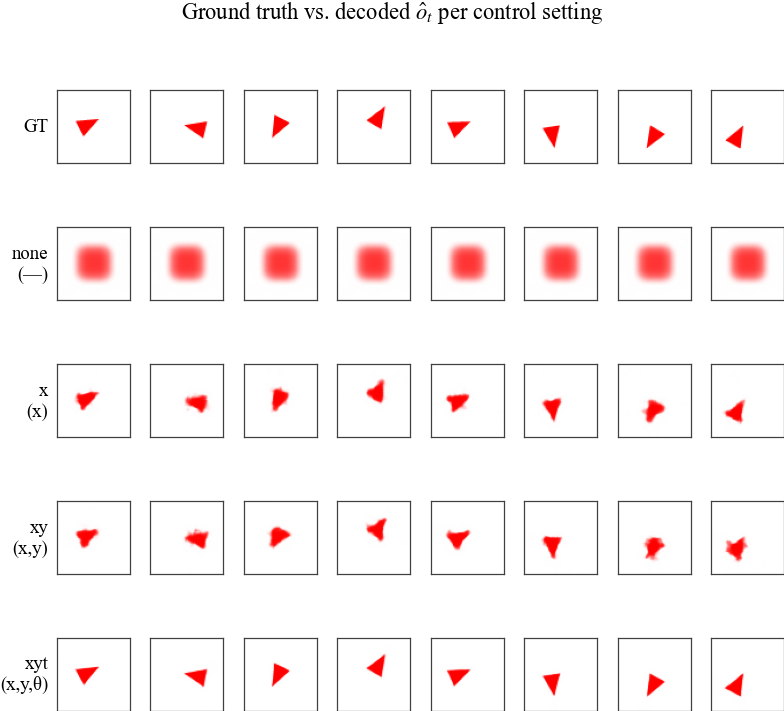

In [24]:
if not HAS_DECODERS:
    print("No trained decoders found — run train_decoder.py first.")
else:
    K = 8
    idx = np.random.default_rng(0).choice(obs_np.shape[0], size=K, replace=False)
    nrow = 1 + len(RUNS)
    fig, axes = plt.subplots(nrow, K, figsize=(FULL_WIDTH, 1.05 * nrow))
    for j, ix in enumerate(idx):
        axes[0, j].imshow(to_img(obs_np[ix]))
        for r, run in enumerate(RUNS):
            axes[r + 1, j].imshow(to_img(recon[run][ix]))
    for ax in axes.ravel():
        ax.set_xticks([]); ax.set_yticks([])
    axes[0, 0].set_ylabel("GT", rotation=0, ha="right", va="center")
    for r, run in enumerate(RUNS):
        axes[r + 1, 0].set_ylabel(f"{run}\n({dof_label(run)})", rotation=0, ha="right", va="center")
    fig.suptitle("Ground truth vs. decoded $\\hat{o}_t$ per control setting")
    fig.tight_layout()
    plt.show()

## 2 — Overall reconstruction MSE

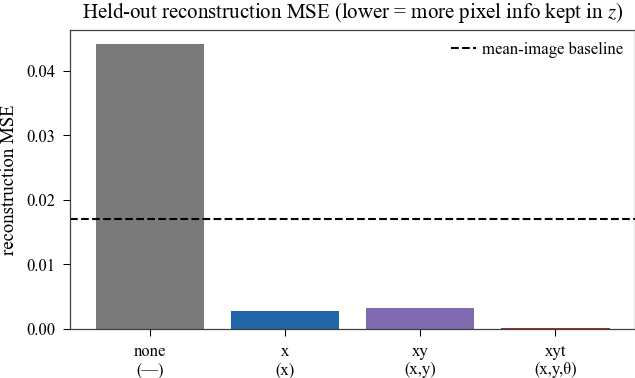

  none  MSE=0.04412  (2.60× baseline)
  x     MSE=0.00274  (0.16× baseline)
  xy    MSE=0.00323  (0.19× baseline)
  xyt   MSE=0.00019  (0.01× baseline)


In [25]:
if HAS_DECODERS:
    baseline = float(((obs_np - obs_np.mean(axis=0, keepdims=True)) ** 2).mean())
    mses = [float(per_sample_mse(r).mean()) for r in RUNS]
    fig, ax = plt.subplots(figsize=figure_size(HALF_WIDTH * 1.7, ratio=0.62))
    ax.bar(range(len(RUNS)), mses, color=[RUN_COLOR[r] for r in RUNS])
    ax.axhline(baseline, ls="--", lw=1.0, color=palette["Black"], label="mean-image baseline")
    ax.set_xticks(range(len(RUNS)))
    ax.set_xticklabels([f"{r}\n({dof_label(r)})" for r in RUNS])
    ax.set_ylabel("reconstruction MSE")
    ax.set_title("Held-out reconstruction MSE (lower = more pixel info kept in $z$)")
    ax.legend()
    fig.tight_layout()
    plt.show()
    for r, m in zip(RUNS, mses):
        print(f"  {r:4s}  MSE={m:.5f}  ({m / baseline:.2f}× baseline)")